In [8]:
import pandas as pd

In [9]:
from google.colab import files
uploaded = files.upload()

Saving Lab Session Data.xlsx to Lab Session Data (2).xlsx


In [10]:
import os
print(os.listdir())

['.config', 'Lab Session Data.xlsx', 'Lab Session Data (2).xlsx', 'Lab Session Data (1).xlsx', 'sample_data']


In [11]:
excel = pd.ExcelFile("Lab Session Data.xlsx")
print(excel.sheet_names)

['Purchase data', 'IRCTC Stock Price', 'thyroid0387_UCI', 'marketing_campaign']


In [12]:
df = pd.read_excel("Lab Session Data.xlsx", sheet_name="Purchase data")

In [13]:
df.head()

,Customer,Candies (#),Mangoes (Kg),Milk Packets (#),Payment (Rs),Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Candy,Mango,Milk
0,C_1,20,6,2,386,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,55.0,18.0
1,C_2,16,3,6,289,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C_3,27,6,2,393,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C_4,19,1,2,110,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C_5,24,4,2,280,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df = df[["Customer", "Candies (#)", "Mangoes (Kg)", "Milk Packets (#)", "Payment (Rs)"]]

df.head()

,Customer,Candies (#),Mangoes (Kg),Milk Packets (#),Payment (Rs)
0,C_1,20,6,2,386
1,C_2,16,3,6,289
2,C_3,27,6,2,393
3,C_4,19,1,2,110
4,C_5,24,4,2,280


In [15]:
X = df[["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]]

y = df["Payment (Rs)"]

print("Feature Matrix (X):")
print(X)

print("\nOutput Vector (y):")
print(y)

Feature Matrix (X):
   Candies (#)  Mangoes (Kg)  Milk Packets (#)
0           20             6                 2
1           16             3                 6
2           27             6                 2
3           19             1                 2
4           24             4                 2
5           22             1                 5
6           15             4                 2
7           18             4                 2
8           21             1                 4
9           16             2                 4

Output Vector (y):
0    386
1    289
2    393
3    110
4    280
5    167
6    271
7    274
8    148
9    198
Name: Payment (Rs), dtype: int64


In [16]:
print("Dimensionality:", X.shape[1])

Dimensionality: 3


In [17]:
print("Number of vectors:", X.shape[0])

Number of vectors: 10


In [18]:
import numpy as np
rank = np.linalg.matrix_rank(X)
print("Rank of Feature Matrix:", rank)

Rank of Feature Matrix: 3


In [19]:
X_pseudo = np.linalg.pinv(X)
cost = X_pseudo @ y
print("Candy Cost        :", cost[0])
print("Mango Cost (Kg)   :", cost[1])
print("Milk Packet Cost  :", cost[2])

Candy Cost        : 0.9999999999999989
Mango Cost (Kg)   : 54.99999999999999
Milk Packet Cost  : 18.0


In [20]:
print("Candy Cost        :", round(cost[0], 2))
print("Mango Cost (Kg)   :", round(cost[1], 2))
print("Milk Packet Cost  :", round(cost[2], 2))

Candy Cost        : 1.0
Mango Cost (Kg)   : 55.0
Milk Packet Cost  : 18.0


In [21]:
# A2 - Customer Classification (RICH / POOR)

import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Create RICH / POOR class
df["Class"] = df["Payment (Rs)"].apply(lambda x: "RICH" if x > 200 else "POOR")

# Select input features
X = df[["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]]

# Select output
y = df["Class"]

# Create Decision Tree model
model = DecisionTreeClassifier()

# Train the model
model.fit(X, y)

# Predict the class
prediction = model.predict(X)

# Add prediction to the dataframe
df["Predicted Class"] = prediction

# Display the result
print(df[["Customer", "Payment (Rs)", "Class", "Predicted Class"]])

  Customer  Payment (Rs) Class Predicted Class
0      C_1           386  RICH            RICH
1      C_2           289  RICH            RICH
2      C_3           393  RICH            RICH
3      C_4           110  POOR            POOR
4      C_5           280  RICH            RICH
5      C_6           167  POOR            POOR
6      C_7           271  RICH            RICH
7      C_8           274  RICH            RICH
8      C_9           148  POOR            POOR
9     C_10           198  POOR            POOR


First 5 Rows:
           Date Month  Day    Price     Open     High      Low   Volume  \
0  Jun 29, 2021   Jun  Tue  2081.85  2092.00  2126.90  2065.05    1.67M   
1  Jun 28, 2021   Jun  Mon  2077.75  2084.00  2112.45  2068.40  707.73K   
2  Jun 25, 2021   Jun  Fri  2068.85  2084.35  2088.50  2053.10  475.82K   
3  Jun 24, 2021   Jun  Thu  2072.95  2098.00  2098.00  2066.00  541.51K   
4  Jun 23, 2021   Jun  Wed  2078.25  2102.00  2111.40  2072.00  809.62K   

     Chg%  
0  0.0020  
1  0.0043  
2 -0.0020  
3 -0.0026  
4 -0.0023  

Mean Price: 1560.6634538152612
Variance: 58732.36535253922

My Mean: 1560.6634538152598
My Variance: 58732.36535253922

Wednesday Mean: 1550.7060000000001
April Mean: 1698.9526315789474

Probability of Loss: 0.4979919678714859
Probability of Profit on Wednesday: 0.08433734939759036
Conditional Probability: 0.42


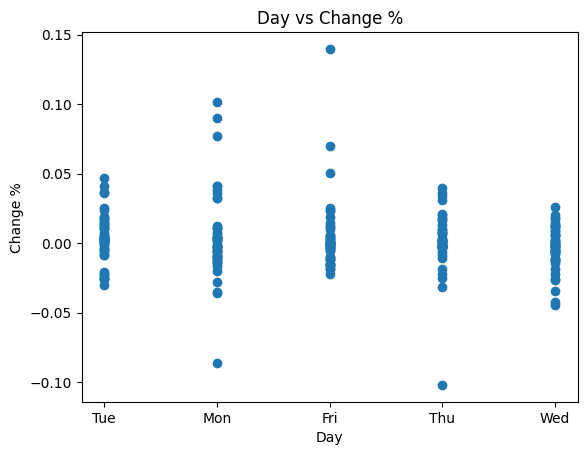

In [22]:
# A3 - IRCTC Stock Price Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the IRCTC Stock Price sheet
stock = pd.read_excel("Lab Session Data.xlsx", sheet_name="IRCTC Stock Price")

# Display first 5 rows
print("First 5 Rows:")
print(stock.head())

# Mean and Variance using Pandas
mean_price = stock["Price"].mean()
variance_price = stock["Price"].var()

print("\nMean Price:", mean_price)
print("Variance:", variance_price)

# User-defined Mean Function
def my_mean(data):
    total = 0
    for i in data:
        total = total + i
    return total / len(data)

# User-defined Variance Function
def my_variance(data):
    mean = my_mean(data)
    total = 0
    for i in data:
        total = total + (i - mean) ** 2
    return total / (len(data) - 1)

print("\nMy Mean:", my_mean(stock["Price"]))
print("My Variance:", my_variance(stock["Price"]))

# Wednesday Mean
wednesday = stock[stock["Day"] == "Wed"]
print("\nWednesday Mean:", wednesday["Price"].mean())

# April Mean
april = stock[stock["Month"] == "Apr"]
print("April Mean:", april["Price"].mean())

# Probability of Loss
loss = len(stock[stock["Chg%"] < 0])
prob_loss = loss / len(stock)
print("\nProbability of Loss:", prob_loss)

# Probability of Profit on Wednesday
profit_wed = len(stock[(stock["Day"] == "Wed") & (stock["Chg%"] > 0)])
prob_profit_wed = profit_wed / len(stock)
print("Probability of Profit on Wednesday:", prob_profit_wed)

# Conditional Probability of Profit given Wednesday
profit = len(wednesday[wednesday["Chg%"] > 0])
conditional = profit / len(wednesday)
print("Conditional Probability:", conditional)

# Scatter Plot
plt.scatter(stock["Day"], stock["Chg%"])
plt.title("Day vs Change %")
plt.xlabel("Day")
plt.ylabel("Change %")
plt.show()

In [23]:
import time
# Compare execution time of Mean
numpy_mean_time = 0
my_mean_time = 0
for i in range(10):
    start = time.time()
    stock["Price"].mean()
    end = time.time()
    numpy_mean_time += (end - start)

    start = time.time()
    my_mean(stock["Price"])
    end = time.time()
    my_mean_time += (end - start)
print("Average NumPy Mean Time:", numpy_mean_time / 10)
print("Average My Mean Time:", my_mean_time / 10)
# Compare execution time of Variance
numpy_var_time = 0
my_var_time = 0

for i in range(10):
    start = time.time()
    stock["Price"].var()
    end = time.time()
    numpy_var_time += (end - start)

    start = time.time()
    my_variance(stock["Price"])
    end = time.time()
    my_var_time += (end - start)

print("Average NumPy Variance Time:", numpy_var_time / 10)
print("Average My Variance Time:", my_var_time / 10)

Average NumPy Mean Time: 0.00011298656463623046
Average My Mean Time: 3.7503242492675784e-05
Average NumPy Variance Time: 8.327960968017578e-05
Average My Variance Time: 0.00014410018920898437


First 5 Rows
   Record ID  age sex on thyroxine query on thyroxine  \
0  840801013   29   F            f                  f   
1  840801014   29   F            f                  f   
2  840801042   41   F            f                  f   
3  840803046   36   F            f                  f   
4  840803047   32   F            f                  f   

  on antithyroid medication sick pregnant thyroid surgery I131 treatment  ...  \
0                         f    f        f               f              f  ...   
1                         f    f        f               f              f  ...   
2                         f    f        f               f              f  ...   
3                         f    f        f               f              f  ...   
4                         f    f        f               f              f  ...   

  TT4 measured  TT4 T4U measured T4U FTI measured FTI TBG measured TBG  \
0            f    ?            f   ?            f   ?            f   ?   
1        

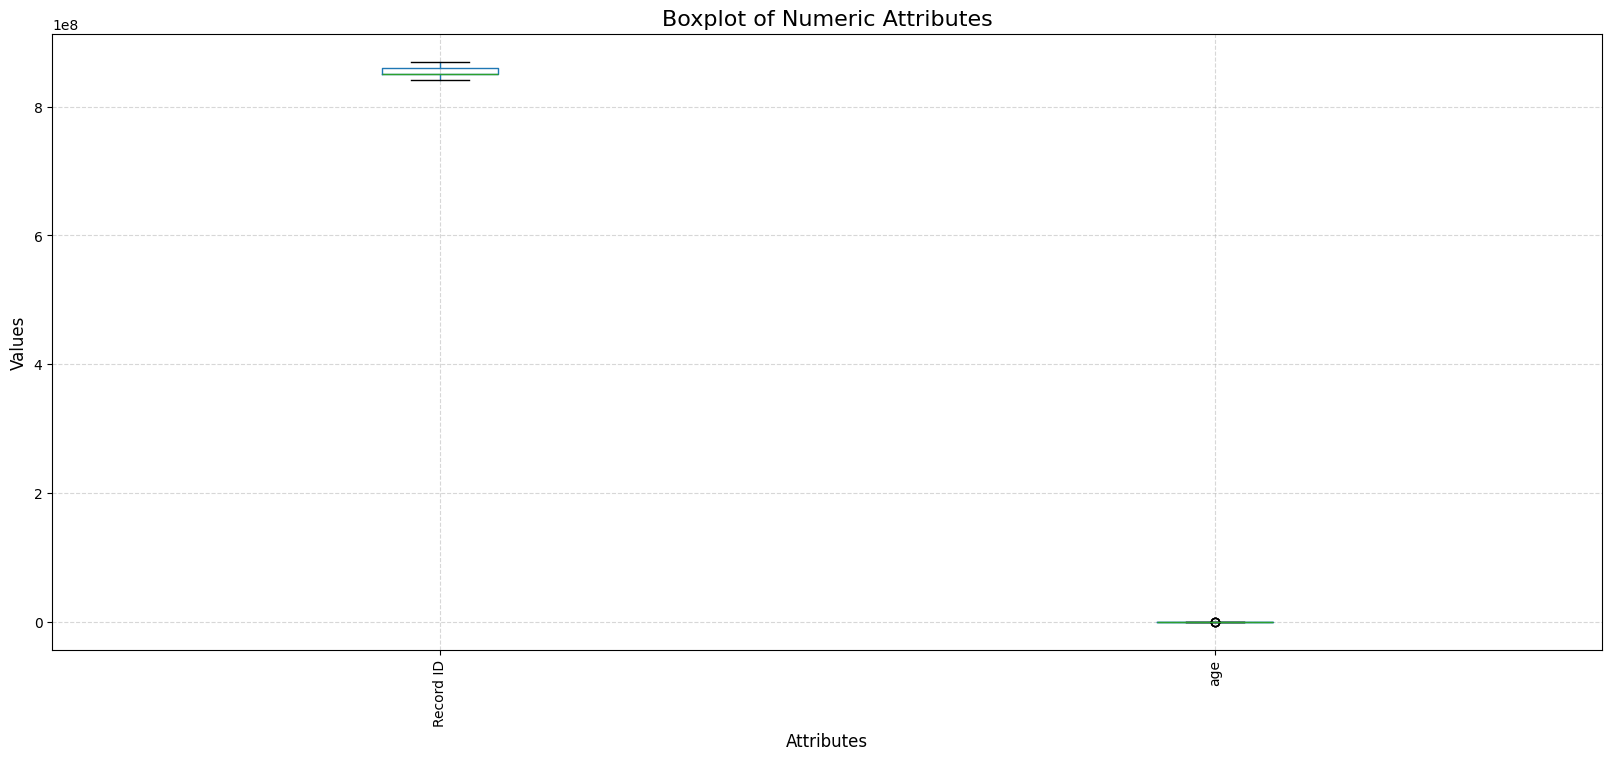

In [24]:
# A4 - Data Exploration
import pandas as pd
import matplotlib.pyplot as plt
# Load Thyroid Dataset
thyroid = pd.read_excel("Lab Session Data.xlsx", sheet_name="thyroid0387_UCI")
# Display Dataset Information
print("First 5 Rows")
print(thyroid.head())
print("\nShape of Dataset")
print(thyroid.shape)
print("\nColumn Names")
print(thyroid.columns)
print("\nData Types")
print(thyroid.dtypes)
# Missing Values
print("\nMissing Values")
print(thyroid.isnull().sum())
# Numeric and Categorical Columns
numeric = thyroid.select_dtypes(include=["int64","float64"])
categorical = thyroid.select_dtypes(include=["object"])
print("\nNumeric Columns")
print(numeric.columns)
print("\nCategorical Columns")
print(categorical.columns)
# Mean
print("\nMean")
print(numeric.mean())
# Variance
print("\nVariance")
print(numeric.var())
# Standard Deviation
print("\nStandard Deviation")
print(numeric.std())
# Summary Statistics
print("\nSummary Statistics")
print(numeric.describe())
# Better Boxplot for Outliers
plt.figure(figsize=(20,8))

numeric.boxplot(
    rot=90,
    fontsize=10
)

plt.title("Boxplot of Numeric Attributes", fontsize=16)
plt.xlabel("Attributes", fontsize=12)
plt.ylabel("Values", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [25]:
# A5 - Jaccard Coefficient and Simple Matching Coefficient

import pandas as pd
# Load dataset
thyroid = pd.read_excel("Lab Session Data.xlsx", sheet_name="thyroid0387_UCI")
# Take first two rows
row1 = thyroid.iloc[0]
row2 = thyroid.iloc[1]
# Counters
f11 = 0
f10 = 0
f01 = 0
f00 = 0
# Compare only binary columns
for col in thyroid.columns:
    value1 = str(row1[col]).lower()
    value2 = str(row2[col]).lower()
    # Check if column has binary values
    if value1 in ["t","f","0","1"] and value2 in ["t","f","0","1"]:
        if value1 == "1" or value1 == "t":
            if value2 == "1" or value2 == "t":
                f11 += 1
            else:
                f10 += 1
        else:
            if value2 == "1" or value2 == "t":
                f01 += 1
            else:
                f00 += 1

# Calculate JC
JC = f11 / (f11 + f10 + f01)

# Calculate SMC
SMC = (f11 + f00) / (f11 + f10 + f01 + f00)

# Print Results
print("f11 =", f11)
print("f10 =", f10)
print("f01 =", f01)
print("f00 =", f00)

print("\nJaccard Coefficient =", JC)
print("Simple Matching Coefficient =", SMC)

f11 = 1
f10 = 1
f01 = 2
f00 = 17

Jaccard Coefficient = 0.25
Simple Matching Coefficient = 0.8571428571428571


In [26]:
# A6 - Cosine Similarity

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
thyroid = pd.read_excel("Lab Session Data.xlsx", sheet_name="thyroid0387_UCI")

# Convert categorical values to numbers
encoder = LabelEncoder()

for col in thyroid.columns:
    thyroid[col] = encoder.fit_transform(thyroid[col].astype(str))

# Take first two rows
row1 = thyroid.iloc[0].values.reshape(1, -1)
row2 = thyroid.iloc[1].values.reshape(1, -1)

# Calculate cosine similarity
similarity = cosine_similarity(row1, row2)

print("Cosine Similarity:")
print(similarity)

Cosine Similarity:
[[0.81955989]]


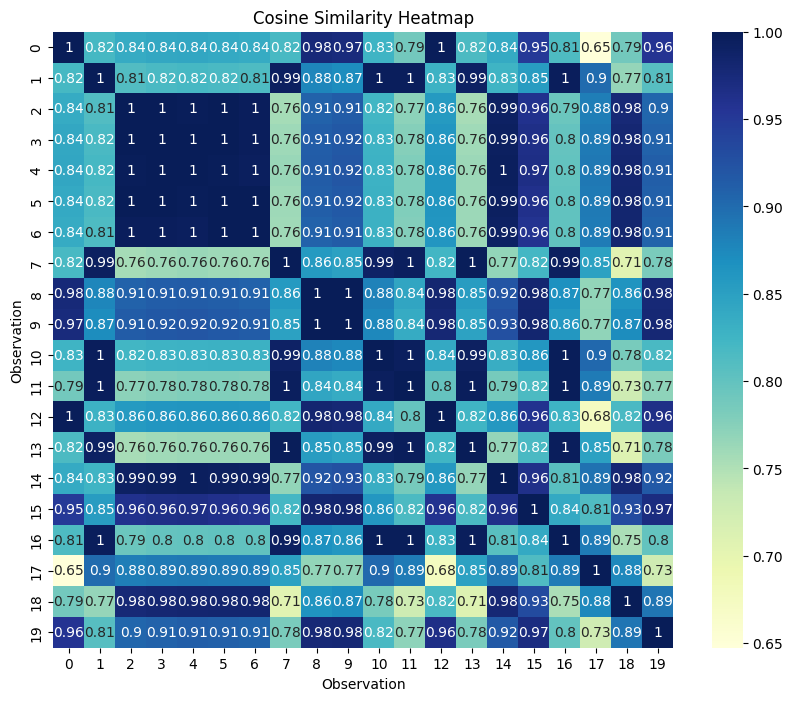

In [27]:
# A7 - Heatmap using Cosine Similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
# Load dataset
thyroid = pd.read_excel("Lab Session Data.xlsx", sheet_name="thyroid0387_UCI")
# Convert categorical values to numbers
encoder = LabelEncoder()
for col in thyroid.columns:
    thyroid[col] = encoder.fit_transform(thyroid[col].astype(str))
# Take first 20 rows
data = thyroid.iloc[:20]
# Calculate cosine similarity
similarity = cosine_similarity(data)
# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    similarity,
    annot=True,
    cmap="YlGnBu"
)
plt.title("Cosine Similarity Heatmap")
plt.xlabel("Observation")
plt.ylabel("Observation")
plt.show()

In [28]:
# A8 - Missing Value Imputation
import pandas as pd
# Load dataset
thyroid = pd.read_excel("Lab Session Data.xlsx", sheet_name="thyroid0387_UCI")
# Fill missing values
for col in thyroid.columns:
    if thyroid[col].dtype == "object":
        thyroid[col].fillna(thyroid[col].mode()[0], inplace=True)
    else:
        thyroid[col].fillna(thyroid[col].median(), inplace=True)
print("Missing Values After Imputation")
print(thyroid.isnull().sum())

Missing Values After Imputation
Record ID                    0
age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
TBG                          0
referral source              0
Condition                    0
dtype: 

/tmp/ipykernel_914/3631634704.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  thyroid[col].fillna(thyroid[col].median(), inplace=True)
/tmp/ipykernel_914/3631634704.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [29]:
# A9 - Data Normalization
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
# Load dataset
thyroid = pd.read_excel("Lab Session Data.xlsx", sheet_name="thyroid0387_UCI")
# Select only numeric columns
numeric = thyroid.select_dtypes(include=["int64", "float64"])
# Create scaler
scaler = MinMaxScaler()
# Normalize the numeric columns
normalized_data = scaler.fit_transform(numeric)
# Convert back to DataFrame
normalized_data = pd.DataFrame(normalized_data, columns=numeric.columns)
# Display first 5 rows
print(normalized_data.head())

      Record ID       age
0  0.000000e+00  0.000427
1  3.410871e-08  0.000427
2  9.891527e-07  0.000610
3  6.934301e-05  0.000534
4  6.937712e-05  0.000473
